# Construcción de dataset por hoja (estadísticas espectrales)

Este notebook crea un dataset tabular donde **cada fila representa una hoja**.

Para cada banda se calculan estadísticas resumen:
- media
- mediana
- desviación estándar
- percentil 10
- percentil 25
- percentil 75
- percentil 90
- opcional: coeficiente de variación (`std / media`)

Salida esperada por cultivo:
- `datasets/dataset_<cultivo>_leaf_stats_train.csv`
- `datasets/dataset_<cultivo>_leaf_stats_test.csv`
- `datasets/object_split_<cultivo>_leaf_stats.csv`

In [1]:
import os
import re
import time
import warnings
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt

import cv2
import numpy as np
import pandas as pd
from scipy.io import loadmat


In [2]:
# Configuración general
RUTA_PRINCIPAL = "data/mat"
CULTIVOS = ["frijol", "maiz"]

LONGITUDES_DE_ONDA = [444, 475, 531, 560, 650, 668, 705, 717, 740, 848]

# Estadísticas requeridas por banda
BASE_STATS = ["mean", "median", "std", "p10", "p25", "p75", "p90"]
INCLUDE_CV_FEATURE = True

MIN_AREA_FRIJOL = 120
MIN_AREA_MAIZ = 200
OPENING_KERNEL = 3

SPLIT_SEED = 42
TRAIN_RATIO = 0.7

os.makedirs("datasets", exist_ok=True)

ALL_STATS = BASE_STATS + (["cv"] if INCLUDE_CV_FEATURE else [])
print("Estadísticas por banda:", ALL_STATS)
print("N features esperadas por hoja (solo bandas):", len(LONGITUDES_DE_ONDA) * len(ALL_STATS))

Estadísticas por banda: ['mean', 'median', 'std', 'p10', 'p25', 'p75', 'p90', 'cv']
N features esperadas por hoja (solo bandas): 80


In [3]:
def cargar_imagen_mat(filepath: str) -> np.ndarray:
    """Carga cubo multiespectral desde .mat con clave 'R'."""
    return loadmat(filepath)["R"]


def cargar_mask_mat(filepath: str) -> np.ndarray:
    """Carga máscara de clases desde .mat con clave 'class_map'."""
    return loadmat(filepath)["class_map"]


def extraer_tratamiento(nombre_archivo_sin_ext: str) -> int:
    """Extrae tratamiento T+ desde el nombre de archivo."""
    m = re.search(r"_T(\d+)", nombre_archivo_sin_ext)
    return int(m.group(1)) if m else 0


def extraer_genotipos_maiz(nombre_archivo: str) -> List[int]:
    """
    Extrae genotipos del patrón ...R<rep>G<id>(G<id>)* al final.
    Ej: REF__0002_T1R1G10G4.mat -> [10, 4]
    """
    base = os.path.splitext(nombre_archivo)[0]
    m = re.search(r"R\d+((?:G\d+)+)$", base)
    if not m:
        gens = re.findall(r"G\d+", base)
    else:
        gens = re.findall(r"G\d+", m.group(1))
    return [int(g[1:]) for g in gens]


def construir_objetos_desde_mask(
    mask: np.ndarray,
    min_area: float,
    opening_kernel: int = 3,
    use_contours: bool = True,
) -> List[Dict]:
    """
    Construye objetos por class_id y asigna ID local estable.

    Por defecto usa contornos (findContours), lo cual reduce objetos espurios
    pequeños observados en maíz con connected components.
    """
    class_ids = np.unique(mask)
    class_ids = class_ids[class_ids != 0]

    objetos = []

    for class_id in np.sort(class_ids):
        class_mask = (mask == class_id).astype(np.uint8) * 255

        if opening_kernel and opening_kernel > 1:
            kernel = np.ones((opening_kernel, opening_kernel), np.uint8)
            class_mask = cv2.morphologyEx(class_mask, cv2.MORPH_OPEN, kernel)

        if use_contours:
            contours_info = cv2.findContours(
                class_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )
            contours = contours_info[0] if len(contours_info) == 2 else contours_info[1]

            for cnt in contours:
                area = float(cv2.contourArea(cnt))
                if area < float(min_area):
                    continue

                M = cv2.moments(cnt)
                if M.get("m00", 0) != 0:
                    cx = M["m10"] / M["m00"]
                    cy = M["m01"] / M["m00"]
                else:
                    x, y, w, h = cv2.boundingRect(cnt)
                    cx = x + (w / 2.0)
                    cy = y + (h / 2.0)

                object_mask = np.zeros_like(class_mask, dtype=np.uint8)
                cv2.drawContours(object_mask, [cnt], -1, 255, thickness=-1)
                pixels_y, pixels_x = np.where(object_mask > 0)
                if len(pixels_x) == 0:
                    continue

                objetos.append(
                    {
                        "class_id": int(class_id),
                        "pixels_x": pixels_x,
                        "pixels_y": pixels_y,
                        "cx": float(cx),
                        "cy": float(cy),
                        "n_pixels": int(len(pixels_x)),
                    }
                )
        else:
            n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
                class_mask, connectivity=8, ltype=cv2.CV_32S
            )

            for i in range(1, n_labels):
                area = float(stats[i, cv2.CC_STAT_AREA])
                if area < float(min_area):
                    continue

                pixels_y, pixels_x = np.where(labels == i)
                if len(pixels_x) == 0:
                    continue

                cx, cy = centroids[i]
                objetos.append(
                    {
                        "class_id": int(class_id),
                        "pixels_x": pixels_x,
                        "pixels_y": pixels_y,
                        "cx": float(cx),
                        "cy": float(cy),
                        "n_pixels": int(len(pixels_x)),
                    }
                )

    objetos = sorted(objetos, key=lambda o: (o["cy"], o["cx"], o["class_id"]))
    for idx, obj in enumerate(objetos, start=1):
        obj["object_local_id"] = idx

    return objetos


def validar_objetos_contornos(
    mask: np.ndarray,
    original_img: np.ndarray = None,
    min_area: float = 20,
    opening_kernel: int = 3,
    figsize=(14, 6),
) -> Dict[str, int]:
    """
    QA visual de objetos detectados por contornos.

    Verde: contorno válido (area >= min_area).
    Rojo: contorno descartado como ruido.
    """
    mask_local = mask.copy().astype(np.uint8)
    _, mask_bin = cv2.threshold(mask_local, 0, 255, cv2.THRESH_BINARY)

    if opening_kernel and opening_kernel > 1:
        kernel = np.ones((opening_kernel, opening_kernel), np.uint8)
        mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_OPEN, kernel)

    contours_info = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = contours_info[0] if len(contours_info) == 2 else contours_info[1]

    if original_img is None:
        canvas = cv2.cvtColor(mask_bin, cv2.COLOR_GRAY2BGR)
    else:
        if original_img.ndim == 2:
            norm = original_img.astype(np.float32)
            maxv = norm.max() if norm.max() > 0 else 1.0
            norm = (norm / maxv * 255).astype(np.uint8)
            canvas = cv2.cvtColor(norm, cv2.COLOR_GRAY2BGR)
        else:
            canvas = original_img.copy()
            if canvas.dtype != np.uint8:
                maxv = canvas.max() if canvas.max() > 0 else 1.0
                canvas = (canvas.astype(np.float32) / maxv * 255).astype(np.uint8)

    areas = []
    n_valid = 0
    n_rejected = 0

    for cnt in contours:
        area = float(cv2.contourArea(cnt))
        areas.append(area)
        if area >= float(min_area):
            color = (0, 255, 0)
            n_valid += 1
        else:
            color = (0, 0, 255)
            n_rejected += 1
        cv2.drawContours(canvas, [cnt], -1, color, 2)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    axes[0].set_title(
        f"Contornos detectados | validos={n_valid}, ruido={n_rejected}, min_area={min_area}"
    )
    axes[0].axis("off")

    if len(areas) > 0:
        axes[1].hist(areas, bins=min(30, max(5, len(areas))), color="#1f77b4", alpha=0.9)
        axes[1].axvline(min_area, color="red", linestyle="--", linewidth=2, label=f"min_area={min_area}")
        axes[1].set_title("Distribucion de areas de contornos")
        axes[1].set_xlabel("Area")
        axes[1].set_ylabel("Frecuencia")
        axes[1].grid(True, alpha=0.2)
        axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, "Sin contornos detectados", ha="center", va="center")
        axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    print("Resumen validacion contornos:")
    print(f"- total_contornos: {len(contours)}")
    print(f"- objetos_validos: {n_valid}")
    print(f"- ruido_descartado: {n_rejected}")

    return {
        "total_contornos": int(len(contours)),
        "objetos_validos": int(n_valid),
        "ruido_descartado": int(n_rejected),
    }


def resumir_hoja_por_banda(
    image_cube: np.ndarray,
    pixels_y: np.ndarray,
    pixels_x: np.ndarray,
    longitudes_de_onda: List[int],
    include_cv: bool = True,
) -> Dict[str, float]:
    """Calcula estadísticas por banda para una hoja (objeto)."""
    features = {}

    n_channels = image_cube.shape[2]
    if n_channels < len(longitudes_de_onda):
        warnings.warn(
            f"image_cube tiene {n_channels} canales pero se esperan {len(longitudes_de_onda)}. "
            "Se ignoraran las bandas faltantes.",
            RuntimeWarning,
        )
    for channel, banda in enumerate(longitudes_de_onda):
        if channel >= n_channels:
            break

        valores = image_cube[pixels_y, pixels_x, channel].astype(np.float32)

        mean_v = float(np.mean(valores))
        median_v = float(np.median(valores))
        std_v = float(np.std(valores))
        p10_v = float(np.percentile(valores, 10))
        p25_v = float(np.percentile(valores, 25))
        p75_v = float(np.percentile(valores, 75))
        p90_v = float(np.percentile(valores, 90))

        prefix = f"int_{banda}"
        features[f"{prefix}_mean"] = mean_v
        features[f"{prefix}_median"] = median_v
        features[f"{prefix}_std"] = std_v
        features[f"{prefix}_p10"] = p10_v
        features[f"{prefix}_p25"] = p25_v
        features[f"{prefix}_p75"] = p75_v
        features[f"{prefix}_p90"] = p90_v

        if include_cv:
            features[f"{prefix}_cv"] = float(std_v / (mean_v + 1e-6))

    return features


def construir_split_estratificado(
    df_objetos: pd.DataFrame,
    train_ratio: float = 0.7,
    seed: int = 42,
) -> Dict[str, str]:
    """Split train/test estratificado por tratamiento a nivel de la unidad de agrupacion (imagen o hoja)."""
    rng = np.random.default_rng(seed)
    split_map: Dict[str, str] = {}

    for tratamiento in sorted(df_objetos["tratamiento"].dropna().unique()):
        ids = sorted(df_objetos.loc[df_objetos["tratamiento"] == tratamiento, "object_id"].astype(str).tolist())
        if not ids:
            continue

        perm = rng.permutation(len(ids))
        n_train = int(round(len(ids) * float(train_ratio)))
        n_train = max(1, min(n_train, len(ids) - 1)) if len(ids) > 1 else 1

        for rank, idx in enumerate(perm):
            object_id = ids[idx]
            split_map[object_id] = "train" if rank < n_train else "test"

    return split_map


## Validación visual de objetos (findContours)

Antes de construir el dataset completo, valida visualmente los contornos detectados para ajustar `min_area`.


=== Validación visual FRIJOL ===
Archivo REF: REF__0000_T2R1.mat | min_area=120


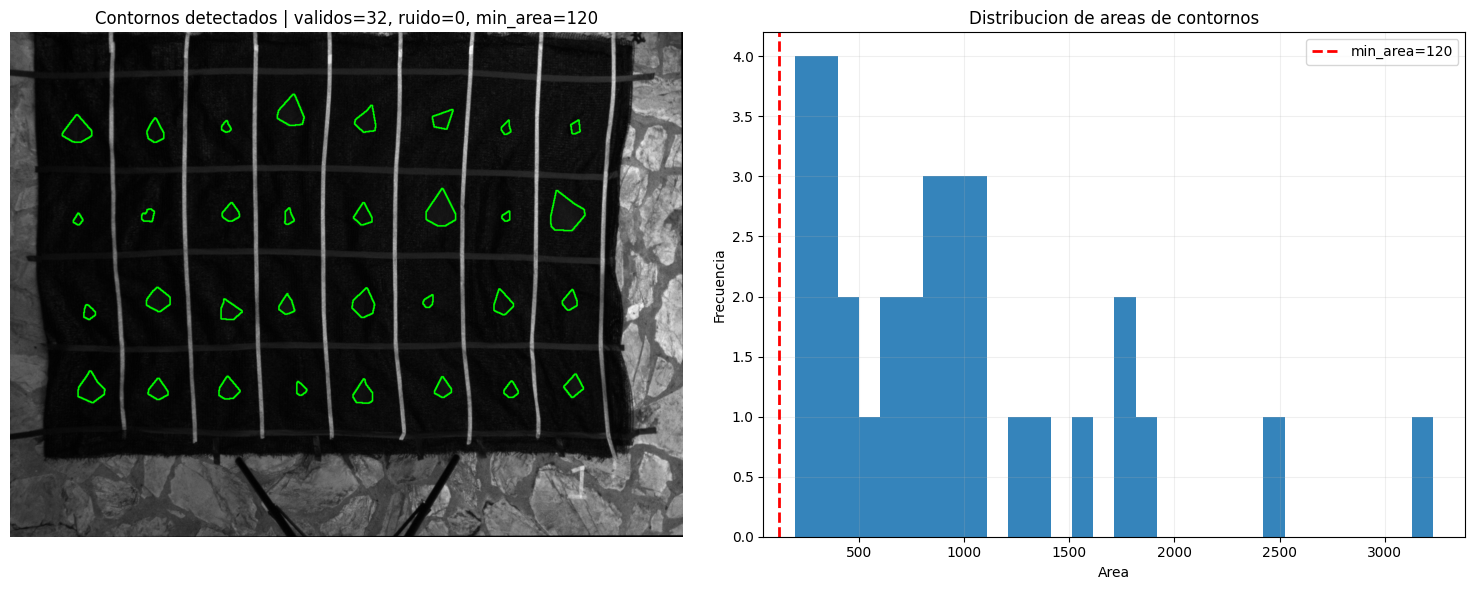

Resumen validacion contornos:
- total_contornos: 32
- objetos_validos: 32
- ruido_descartado: 0

=== Validación visual MAIZ ===
Archivo REF: REF__0002_T1R1G10G4.mat | min_area=200


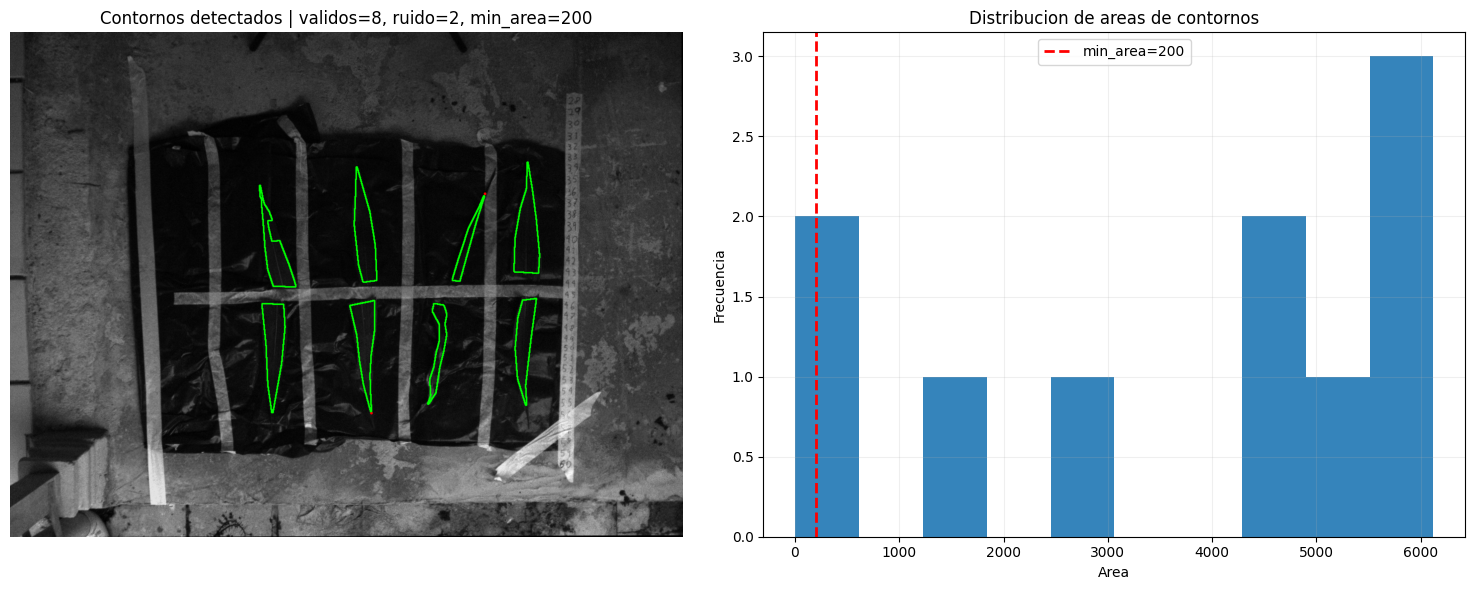

Resumen validacion contornos:
- total_contornos: 10
- objetos_validos: 8
- ruido_descartado: 2


In [4]:
def encontrar_par_ref_class(cultivo: str):
    """Encuentra un par (REF, CLASS) de ejemplo para validación visual."""
    ruta_cultivo = os.path.join(RUTA_PRINCIPAL, cultivo)
    if not os.path.isdir(ruta_cultivo):
        return None, None

    for fecha in sorted(os.listdir(ruta_cultivo)):
        ruta_fecha = os.path.join(ruta_cultivo, fecha)
        if not os.path.isdir(ruta_fecha):
            continue

        masks = [f for f in os.listdir(ruta_fecha) if f.startswith("CLASS") and f.endswith(".mat")]
        images = [f for f in os.listdir(ruta_fecha) if f.startswith("REF") and f.endswith(".mat")]

        masks_dict = {}
        for m in masks:
            key = m.replace("CLASS__", "").replace("CLASS_", "")
            masks_dict[key] = m

        for img_file in sorted(images):
            img_key = img_file.replace("REF__", "").replace("REF_", "")
            mask_file = masks_dict.get(img_key)
            if mask_file is not None:
                return os.path.join(ruta_fecha, img_file), os.path.join(ruta_fecha, mask_file)

    return None, None


# QA visual rápida para fríjol y maíz
for cultivo in CULTIVOS:
    img_path, mask_path = encontrar_par_ref_class(cultivo)
    if img_path is None or mask_path is None:
        print(f"No se encontró par REF/CLASS para {cultivo}")
        continue

    image_cube = cargar_imagen_mat(img_path)
    mask = cargar_mask_mat(mask_path)

    # Usamos una banda media para visualización
    banda_vis = min(5, image_cube.shape[2] - 1)
    original_img = image_cube[:, :, banda_vis]

    min_area = MIN_AREA_FRIJOL if cultivo == "frijol" else MIN_AREA_MAIZ

    print(f"\n=== Validación visual {cultivo.upper()} ===")
    print(f"Archivo REF: {os.path.basename(img_path)} | min_area={min_area}")
    _ = validar_objetos_contornos(
        mask=mask,
        original_img=original_img,
        min_area=min_area,
        opening_kernel=OPENING_KERNEL,
        figsize=(15, 6),
    )

In [5]:
def construir_dataset_por_hoja(cultivo: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Construye dataset por hoja para un cultivo y retorna train, test, manifest."""
    ruta_cultivo = os.path.join(RUTA_PRINCIPAL, cultivo)
    if not os.path.isdir(ruta_cultivo):
        raise FileNotFoundError(f"No existe la ruta del cultivo: {ruta_cultivo}")

    min_area = MIN_AREA_FRIJOL if cultivo == "frijol" else MIN_AREA_MAIZ

    rows = []

    for fecha in sorted(os.listdir(ruta_cultivo)):
        ruta_fecha = os.path.join(ruta_cultivo, fecha)
        if not os.path.isdir(ruta_fecha):
            continue

        masks = [f for f in os.listdir(ruta_fecha) if f.startswith("CLASS") and f.endswith(".mat")]
        images = [f for f in os.listdir(ruta_fecha) if f.startswith("REF") and f.endswith(".mat")]

        masks_dict = {}
        for m in masks:
            key = m.replace("CLASS__", "").replace("CLASS_", "")
            masks_dict[key] = m

        for img_file in sorted(images):
            img_key = img_file.replace("REF__", "").replace("REF_", "")
            mask_file = masks_dict.get(img_key)
            if mask_file is None:
                continue

            img_path = os.path.join(ruta_fecha, img_file)
            mask_path = os.path.join(ruta_fecha, mask_file)

            nombre = os.path.splitext(img_file)[0]
            tratamiento = extraer_tratamiento(nombre)

            try:
                image_cube = cargar_imagen_mat(img_path)
                mask = cargar_mask_mat(mask_path)

                objetos = construir_objetos_desde_mask(mask, min_area=min_area, opening_kernel=OPENING_KERNEL)
                if not objetos:
                    continue

                # Para maíz, mapear class_id de máscara a genotipo real extraído del nombre
                mapping_genotipos = {}
                if cultivo == "maiz":
                    genotipos_archivo = extraer_genotipos_maiz(img_file)
                    if len(genotipos_archivo) == 0:
                        genotipos_archivo = [0]

                    clases_presentes = np.unique(mask)
                    clases_presentes = clases_presentes[clases_presentes != 0]
                    clases_presentes = np.sort(clases_presentes)

                    mapping_genotipos = {
                        int(class_id): int(genotipos_archivo[i % len(genotipos_archivo)])
                        for i, class_id in enumerate(clases_presentes)
                    }

                for obj in objetos:
                    # Incluir fecha en object_id para evitar colisiones entre fechas distintas
                    object_id = f"{fecha}__{nombre}__obj_{obj['object_local_id']:03d}"

                    if cultivo == "frijol":
                        genotipo = int(obj["class_id"])
                    else:
                        genotipo = int(mapping_genotipos.get(int(obj["class_id"]), 0))

                    feat = resumir_hoja_por_banda(
                        image_cube=image_cube,
                        pixels_y=obj["pixels_y"],
                        pixels_x=obj["pixels_x"],
                        longitudes_de_onda=LONGITUDES_DE_ONDA,
                        include_cv=INCLUDE_CV_FEATURE,
                    )

                    row = {
                        "cultivo": cultivo,
                        "fecha": fecha,
                        "nombre_imagen": nombre,
                        "object_id": object_id,
                        "genotipo": genotipo,
                        "tratamiento": int(tratamiento),
                        "n_pixels": int(obj["n_pixels"]),
                    }
                    row.update(feat)
                    rows.append(row)

            except Exception as e:
                print(f"Error procesando {img_path}: {e}")

    if not rows:
        raise ValueError(f"No se generaron filas para cultivo={cultivo}.")

    df = pd.DataFrame(rows).drop_duplicates(subset=["object_id"]).reset_index(drop=True)

    # Split estratificado por tratamiento a nivel de hoja (object_id)
    df_leaves = df[["object_id", "tratamiento"]].copy().reset_index(drop=True)
    split_map = construir_split_estratificado(df_leaves, train_ratio=TRAIN_RATIO, seed=SPLIT_SEED)
    df["split"] = df["object_id"].map(split_map)

    if df["split"].isna().any():
        faltantes = int(df["split"].isna().sum())
        raise ValueError(f"Hay {faltantes} objetos sin split asignado.")

    manifest = df[["object_id", "tratamiento", "split"]].copy()
    manifest = manifest.sort_values(["tratamiento", "object_id"]).reset_index(drop=True)

    df_train = df[df["split"] == "train"].copy().reset_index(drop=True)
    df_test = df[df["split"] == "test"].copy().reset_index(drop=True)

    return df_train, df_test, manifest


In [ ]:
t0 = time.time()

resultados = {}

for cultivo in CULTIVOS:
    print(f"\n=== Construyendo dataset por hoja: {cultivo.upper()} ===")

    df_train, df_test, manifest = construir_dataset_por_hoja(cultivo)

    out_train = f"datasets/dataset_{cultivo}_leaf_stats_train.csv"
    out_test = f"datasets/dataset_{cultivo}_leaf_stats_test.csv"
    out_manifest = f"datasets/object_split_{cultivo}_leaf_stats.csv"

    df_train.to_csv(out_train, index=False)
    df_test.to_csv(out_test, index=False)
    manifest.to_csv(out_manifest, index=False)

    resultados[cultivo] = {
        "train": df_train,
        "test": df_test,
        "manifest": manifest,
        "paths": {
            "train": out_train,
            "test": out_test,
            "manifest": out_manifest,
        },
    }

    print(f"train: {out_train} -> {len(df_train)} hojas")
    print(f"test:  {out_test} -> {len(df_test)} hojas")
    print(f"manifest: {out_manifest} -> {len(manifest)} hojas")

print(f"\nTiempo total: {time.time() - t0:.2f} s")

In [7]:
def qa_dataset_por_hoja(df_train: pd.DataFrame, df_test: pd.DataFrame, manifest: pd.DataFrame, cultivo: str):
    print(f"\n=== QA dataset por hoja: {cultivo.upper()} ===")

    df_all = pd.concat([df_train, df_test], ignore_index=True)

    # Columnas esperadas
    feature_cols = [c for c in df_all.columns if c.startswith("int_")]
    required = ["cultivo", "fecha", "nombre_imagen", "object_id", "genotipo", "tratamiento", "n_pixels", "split"]

    missing_required = [c for c in required if c not in df_all.columns]
    if missing_required:
        print("❌ Faltan columnas requeridas:", missing_required)
        return

    print("Columnas feature por banda:", len(feature_cols))
    print("Total filas (hojas):", len(df_all))

    # Sin fuga train/test
    ids_train = set(df_train["object_id"].astype(str).unique())
    ids_test = set(df_test["object_id"].astype(str).unique())
    overlap = ids_train & ids_test
    if overlap:
        print(f"❌ Fuga detectada: {len(overlap)} object_id en train y test")
    else:
        print("✅ Sin fuga entre train y test")

    # Consistencia con manifest
    manifest_map = manifest.set_index("object_id")["split"].to_dict()
    split_manifest = df_all["object_id"].map(manifest_map)
    mismatch = int((split_manifest != df_all["split"]).sum())
    if mismatch > 0:
        print(f"❌ Inconsistencias split vs manifest: {mismatch}")
    else:
        print("✅ split consistente con manifest")

    # Ratio por hoja
    c = manifest["split"].value_counts()
    n_train = int(c.get("train", 0))
    n_test = int(c.get("test", 0))
    ratio = n_train / max(1, (n_train + n_test))
    print(f"Ratio train/test por hoja: {n_train}/{n_test} -> {ratio:.3f}")

    # Nulos
    nulls = df_all[required + feature_cols].isna().sum().sum()
    print("Nulos totales:", int(nulls))

    # Distribución por tratamiento y split
    tabla = manifest.groupby(["tratamiento", "split"]).size().unstack(fill_value=0)
    print("\nDistribución por tratamiento y split:")
    print(tabla.to_string())

    # Vista rápida de columnas
    print("\nPrimeras columnas feature:", feature_cols[:8])


for cultivo in CULTIVOS:
    qa_dataset_por_hoja(
        resultados[cultivo]["train"],
        resultados[cultivo]["test"],
        resultados[cultivo]["manifest"],
        cultivo,
    )


=== QA dataset por hoja: FRIJOL ===
Columnas feature por banda: 80
Total filas (hojas): 382
✅ Sin fuga entre train y test
✅ split consistente con manifest
Ratio train/test por hoja: 267/115 -> 0.699
Nulos totales: 0

Distribución por tratamiento y split:
split        test  train
tratamiento             
1              29     67
2              29     67
3              29     67
4              28     66

Primeras columnas feature: ['int_444_mean', 'int_444_median', 'int_444_std', 'int_444_p10', 'int_444_p25', 'int_444_p75', 'int_444_p90', 'int_444_cv']

=== QA dataset por hoja: MAIZ ===
Columnas feature por banda: 80
Total filas (hojas): 573
✅ Sin fuga entre train y test
✅ split consistente con manifest
Ratio train/test por hoja: 401/172 -> 0.700
Nulos totales: 0

Distribución por tratamiento y split:
split        test  train
tratamiento             
1              55    130
2              50    116
3              34     78
4              33     77

Primeras columnas feature: ['int_444_

In [8]:
# Ejemplo rápido de estructura final
for cultivo in CULTIVOS:
    print(f"\n--- Vista previa: {cultivo.upper()} (train) ---")
    display(resultados[cultivo]["train"].head(3))


--- Vista previa: FRIJOL (train) ---


,cultivo,fecha,nombre_imagen,object_id,genotipo,tratamiento,n_pixels,int_444_mean,int_444_median,int_444_std,...,int_740_cv,int_848_mean,int_848_median,int_848_std,int_848_p10,int_848_p25,int_848_p75,int_848_p90,int_848_cv,split
0,frijol,Nov_3_2021,REF__0000_T2R1,Nov_3_2021__REF__0000_T2R1__obj_003,5,2,1321,2.337686,2.372227,0.402815,...,0.047763,24.423397,24.459316,0.987695,23.159353,23.788681,25.068621,25.650816,0.040441,train
1,frijol,Nov_3_2021,REF__0000_T2R1,Nov_3_2021__REF__0000_T2R1__obj_004,3,2,281,1.672952,1.702158,0.335129,...,0.052467,19.623867,19.666580,1.027234,18.251696,19.136990,20.385305,20.848991,0.052346,train
2,frijol,Nov_3_2021,REF__0000_T2R1,Nov_3_2021__REF__0000_T2R1__obj_005,8,2,367,2.355816,2.321483,0.341405,...,0.050010,27.551601,27.787325,1.343999,25.826035,26.890980,28.456085,28.953787,0.048781,train



--- Vista previa: MAIZ (train) ---


,cultivo,fecha,nombre_imagen,object_id,genotipo,tratamiento,n_pixels,int_444_mean,int_444_median,int_444_std,...,int_740_cv,int_848_mean,int_848_median,int_848_std,int_848_p10,int_848_p25,int_848_p75,int_848_p90,int_848_cv,split
0,maiz,Jun_23_2022,REF__0002_T1R1G10G4,Jun_23_2022__REF__0002_T1R1G10G4__obj_001,10,1,6358,2.093570,1.957444,0.697009,...,0.095803,19.454357,19.192318,1.626405,17.700119,18.312347,20.383535,21.496618,0.083601,train
1,maiz,Jun_23_2022,REF__0002_T1R1G10G4,Jun_23_2022__REF__0002_T1R1G10G4__obj_002,10,1,5869,1.849702,1.793198,0.721653,...,0.119060,18.471964,18.079081,1.848344,16.430758,17.137508,19.624283,21.075642,0.100062,train
2,maiz,Jun_23_2022,REF__0002_T1R1G10G4,Jun_23_2022__REF__0002_T1R1G10G4__obj_003,10,1,1922,2.022022,1.984646,0.742165,...,0.129409,25.184301,25.633646,3.013065,21.848291,23.749132,27.083527,28.224915,0.119641,train
